In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [2]:
# Define the Hénon-Heiles system
def henon_heiles(t, z):
    """
    Differential equations for the Hénon-Heiles system.
    
    Parameters:
        t: Time variable (not used as the system is autonomous).
        z: Array [x, y, px, py], the state of the system.
    
    Returns:
        dzdt: Array with derivatives [dx/dt, dy/dt, dpx/dt, dpy/dt].
    """
    x, y, px, py = z
    dxdt = px
    dydt = py
    dpxdt = -x - 2 * x * y
    dpydt = -y - x**2 + y**2
    return [dxdt, dydt, dpxdt, dpydt]


In [3]:
# Function to compute a Poincaré section
def poincare_section(solution, y0):
    """
    Extract the points for a Poincaré section at y = y0.
    
    Parameters:
        solution: The result of the numerical integration.
        y0: The y-coordinate for the section plane.
    
    Returns:
        x_poincare, px_poincare: Points of the Poincaré section.
    """
    x, y, px, py = solution.y
    indices = np.where(np.isclose(y, y0, atol=1e-2) & (py > 0))[0]
    return x[indices], px[indices]


In [4]:
# Initial parameters
z0 = [0.2, 0.0, 0.0, 0.3]  # Initial conditions: [x, y, px, py]
t_span = (0, 1500)  # Time interval
t_eval = np.linspace(t_span[0], t_span[1], 5000)  # Time evaluation points

# Solve the system of equations
solution = solve_ivp(henon_heiles, t_span, z0, t_eval=t_eval, method="RK45")


In [5]:
# Plot the trajectory in phase space (x vs y)
def plot_phase_space(solution, save=False):
    """
    Plot the trajectory in phase space (x vs y).
    
    Parameters:
        solution: The result of the numerical integration.
        save: Boolean to save the figure.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(solution.y[0], solution.y[1], lw=0.8)
    plt.title("Trajectory in Phase Space (x vs y)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid()
    if save:
        plt.savefig("phase_space.png", dpi=300)
    plt.show()


In [6]:
# Generate and plot the Poincaré section
def plot_poincare_section(solution, y0, save=False):
    """
    Plot the Poincaré section at y = y0.
    
    Parameters:
        solution: The result of the numerical integration.
        y0: The y-coordinate for the section plane.
        save: Boolean to save the figure.
    """
    x_poincare, px_poincare = poincare_section(solution, y0)
    plt.figure(figsize=(8, 6))
    plt.scatter(x_poincare, px_poincare, s=1, c="blue")
    plt.title("Poincaré Section at y = {:.2f}".format(y0))
    plt.xlabel("x")
    plt.ylabel("px")
    plt.grid()
    if save:
        plt.savefig("poincare_section.png", dpi=300)
    plt.show()


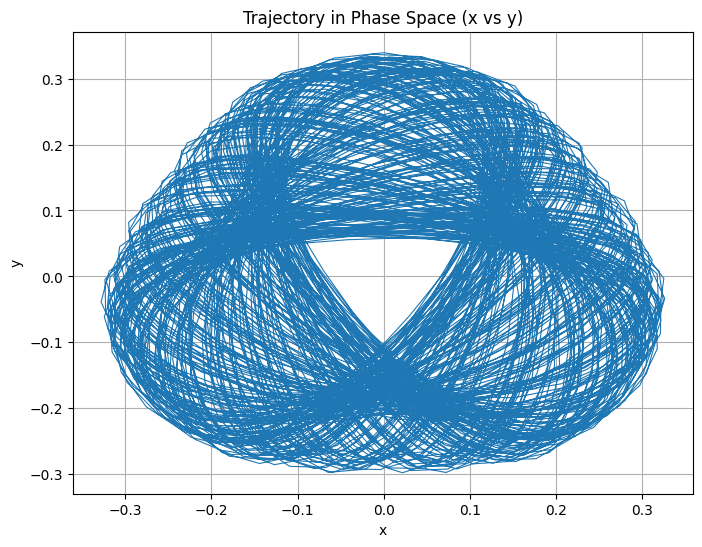

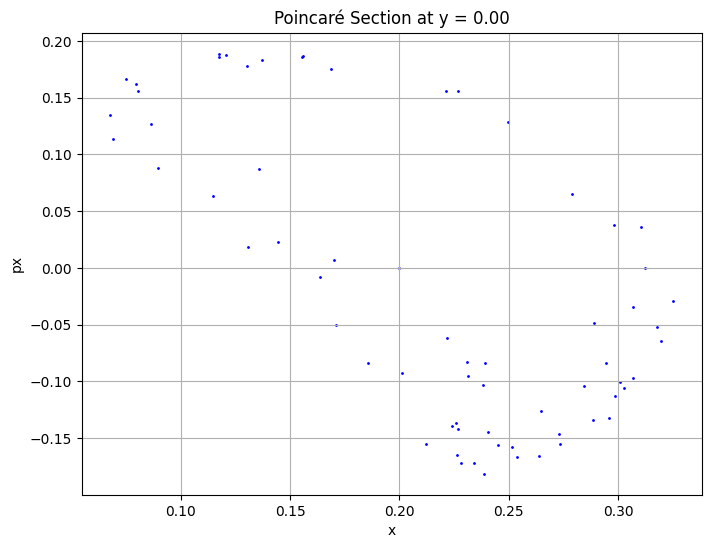

In [7]:
# Plot the results
plot_phase_space(solution, save=True)  # Save the phase space plot
plot_poincare_section(solution, y0=0, save=True)  # Save the Poincaré section
